# Representation Analysis & Robustness Benchmark: Task 1

This Colab notebook sets up the modular repository structure prescribed by the assignment:
```
task1/
├── configs/config.py
├── data/
│   ├── make_subset.py
│   ├── make_cue_conflicts.py
│   └── transforms.py
├── models/
│   └── backbones.py
├── analysis/
│   ├── evaluate_bias.py
│   ├── feature_similarity.py
│   └── representation.py
├── scripts/
│   └── run_task1.py
├── results/
└── README.md
```

It incorporates all your working code from Step 1 (Clean Baseline) and Step 2 (Color Bias: Grayscale + Hue Rotation +180°).

In [ ]:
# Cell 1: Environment Dependencies
!pip install open_clip_torch torchvision scikit-learn pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00


In [ ]:
# Cell 2: Initialize Repository Layout and Directory Structure
import os

dirs = [
    "task1/configs",
    "task1/data",
    "task1/models",
    "task1/analysis",
    "task1/scripts",
    "task1/results"
]

for d in dirs:
    os.makedirs(d, exist_ok=True)

# Create package __init__.py files
init_files = [
    "task1/__init__.py",
    "task1/configs/__init__.py",
    "task1/data/__init__.py",
    "task1/models/__init__.py",
    "task1/analysis/__init__.py",
    "task1/scripts/__init__.py"
]
for f in init_files:
    with open(f, "w") as fp:
        pass

print("Repository folders and packages initialized.")

Repository folders and packages initialized.


In [ ]:
%%writefile task1/README.md
# Representation Analysis & Robustness Benchmark (Task 1)

## Suggested Repository Structure Implementation
- `configs/config.py`: Seeds, device configuration, paths, and class labels.
- `data/make_subset.py`: STL-10 dataset loading, 80/20 train/val split, and class-balanced 500-sample test evaluation set.
- `data/transforms.py`: Grayscale, Hue Rotation (+180°), Translation, and Patch Permutation.
- `data/make_cue_conflicts.py`: Stylized cue-conflict image synthesis.
- `models/backbones.py`: ResNet-50, ViT-B/16, and OpenCLIP ViT-B/32 frozen extractors.
- `analysis/evaluate_bias.py`: Linear probe training engine and multi-backbone feature extraction.
- `analysis/feature_similarity.py`: Representation cosine stability (I_T) metric computation.
- `analysis/representation.py`: Dimensionality reduction (t-SNE/UMAP) across clean and intervened representations.
- `scripts/run_task1.py`: Orchestration driver script executing Step 1 (Clean Baseline) and Step 2 (Color Bias).
- `results/`: Persisted outputs, evaluation indices (`eval_500_indices.npy`), and metrics CSVs.

Writing task1/README.md


In [ ]:
%%writefile task1/configs/config.py
import torch

SEED = 6304
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT = "./data_storage"
RESULTS_DIR = "task1/results"

STL10_CLASSES = [
    "airplane", "bird", "car", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

Writing task1/configs/config.py


In [ ]:
%%writefile task1/data/make_subset.py
import os
import numpy as np
import torchvision
from torchvision import transforms
from torch.utils.data import Subset
from sklearn.model_selection import StratifiedShuffleSplit
from task1.configs.config import SEED, DATA_ROOT, RESULTS_DIR

# Common 224x224 RGB base transform prior to model normalization
common_base_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor()
])

def get_datasets():
    os.makedirs(RESULTS_DIR, exist_ok=True)
    os.makedirs(DATA_ROOT, exist_ok=True)

    stl10_train = torchvision.datasets.STL10(
        root=DATA_ROOT, split="train", download=True, transform=common_base_transform
    )
    stl10_test = torchvision.datasets.STL10(
        root=DATA_ROOT, split="test", download=True, transform=common_base_transform
    )

    # 80/20 stratified train/val split using seed 6304
    train_labels = np.array(stl10_train.labels)
    sss_val = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx, val_idx = next(sss_val.split(np.zeros(len(train_labels)), train_labels))

    train_subset = Subset(stl10_train, train_idx)
    val_subset = Subset(stl10_train, val_idx)

    # Stratified class-balanced 500-sample test evaluation subset
    test_labels = np.array(stl10_test.labels)
    sss_test = StratifiedShuffleSplit(n_splits=1, train_size=500, random_state=SEED)
    eval_500_idx, _ = next(sss_test.split(np.zeros(len(test_labels)), test_labels))
    eval_subset = Subset(stl10_test, eval_500_idx)

    # Persist the 500 selected test image identifiers
    np.save(os.path.join(RESULTS_DIR, "eval_500_indices.npy"), eval_500_idx)

    return train_subset, val_subset, eval_subset

Writing task1/data/make_subset.py


In [ ]:
%%writefile task1/data/transforms.py
import torch
from torchvision.transforms import functional as TF

def apply_grayscale(img_tensor):
    """
    Applies ITU-R BT.601 grayscale and replicates across 3 channels.
    img_tensor: [C, H, W] in range [0, 1]
    """
    return TF.rgb_to_grayscale(img_tensor, num_output_channels=3)

def apply_hue_rotation_180(img_tensor):
    """
    Rotates hue by +180 degrees (0.5 in PyTorch range [-0.5, 0.5]).
    Preserves luminance and saturation while altering chromatic polarity.
    """
    return TF.adjust_hue(img_tensor, hue_factor=0.5)

def apply_translation(img_tensor, shift_x, shift_y):
    """
    Translates image using reflection padding followed by a shifted crop.
    img_tensor: [C, H, W]
    """
    c, h, w = img_tensor.shape
    pad = max(abs(shift_x), abs(shift_y))
    if pad == 0:
        return img_tensor
    padded = TF.pad(img_tensor, padding=pad, padding_mode="reflect")
    return TF.crop(padded, top=pad - shift_y, left=pad - shift_x, height=h, width=w)

def apply_patch_shuffle_4x4(img_tensor, generator):
    """
    Divides image into 4x4 grid (16 patches) and applies non-identity permutation.
    """
    c, h, w = img_tensor.shape
    grid_size = 4
    ph, pw = h // grid_size, w // grid_size

    patches = []
    for r in range(grid_size):
        for col in range(grid_size):
            patches.append(img_tensor[:, r * ph:(r + 1) * ph, col * pw:(col + 1) * pw])

    perm = torch.randperm(16, generator=generator)
    while torch.equal(perm, torch.arange(16)):
        perm = torch.randperm(16, generator=generator)

    shuffled_patches = [patches[i] for i in perm]
    rows = []
    for r in range(grid_size):
        row = torch.cat(shuffled_patches[r * grid_size:(r + 1) * grid_size], dim=2)
        rows.append(row)
    return torch.cat(rows, dim=1)

Writing task1/data/transforms.py


In [ ]:
%%writefile task1/data/make_cue_conflicts.py
"""
Placeholder module for cue-conflict image generation.
"""
def generate_cue_conflicts(eval_subset, class_pairs, style_strength=0.8):
    pass

Writing task1/data/make_cue_conflicts.py


In [ ]:
%%writefile task1/models/backbones.py
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights, vit_b_16, ViT_B_16_Weights
import open_clip

class ViTClassTokenExtractor(nn.Module):
    def __init__(self, vit_module):
        super().__init__()
        self.vit = vit_module

    def forward(self, x):
        x = self.vit._process_input(x)
        b = x.shape[0]
        batch_class_token = self.vit.class_token.expand(b, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)
        x = self.vit.encoder(x)
        return x[:, 0]  # [B, 768] CLS token

def load_backbones(device):
    # 1. ResNet-50 (IMAGENET1K_V2)
    r50_weights = ResNet50_Weights.IMAGENET1K_V2
    r50 = resnet50(weights=r50_weights)
    r50.fc = nn.Identity()  # GAP output (2048-d)
    r50_norm = transforms.Normalize(mean=r50_weights.transforms().mean, std=r50_weights.transforms().std)

    # 2. ViT-B/16 (IMAGENET1K_V1)
    vit_weights = ViT_B_16_Weights.IMAGENET1K_V1
    vit_raw = vit_b_16(weights=vit_weights)
    vit = ViTClassTokenExtractor(vit_raw)  # CLS token (768-d)
    vit_norm = transforms.Normalize(mean=vit_weights.transforms().mean, std=vit_weights.transforms().std)

    # 3. OpenCLIP ViT-B/32 (pretrained='openai')
    clip_model, _, _ = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
    clip_norm = transforms.Normalize(mean=(0.48145466, 0.4578275, 0.40821073),
                                     std=(0.26862954, 0.26130258, 0.27577711))

    # Freeze all backbones
    for m in [r50, vit, clip_model]:
        m.to(device)
        m.eval()
        for p in m.parameters():
            p.requires_grad = False

    backbones = {"resnet50": r50, "vit_b16": vit, "clip": clip_model}
    norms = {"resnet50": r50_norm, "vit_b16": vit_norm, "clip": clip_norm}
    return backbones, norms

Writing task1/models/backbones.py


In [ ]:
%%writefile task1/analysis/evaluate_bias.py
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from task1.configs.config import SEED

@torch.no_grad()
def extract_all_backbones(dataset, backbones, norms, device, batch_size=128):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    feats_r50, feats_vit, feats_clip, all_labels = [], [], [], []
    use_amp = torch.cuda.is_available()

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        all_labels.append(labels)

        with torch.amp.autocast("cuda", enabled=use_amp):
            f_r = backbones["resnet50"](norms["resnet50"](imgs))
            f_v = backbones["vit_b16"](norms["vit_b16"](imgs))
            f_c = backbones["clip"].encode_image(norms["clip"](imgs))
            # Explicit normalized CLIP embedding per prompt specification
            f_c = f_c / f_c.norm(dim=-1, keepdim=True)

        feats_r50.append(f_r.float().cpu())
        feats_vit.append(f_v.float().cpu())
        feats_clip.append(f_c.float().cpu())

    targets = torch.cat(all_labels, dim=0)
    return {
        "resnet50": (torch.cat(feats_r50, dim=0), targets),
        "vit_b16": (torch.cat(feats_vit, dim=0), targets),
        "clip": (torch.cat(feats_clip, dim=0), targets),
    }

def train_linear_head(in_dim, train_f, train_y, val_f, val_y, device, seed=SEED):
    torch.manual_seed(seed)
    head = nn.Linear(in_dim, 10).to(device)
    nn.init.normal_(head.weight, std=0.1)
    nn.init.zeros_(head.bias)

    optimizer = torch.optim.AdamW(head.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    train_loader = DataLoader(list(zip(train_f, train_y)), batch_size=64, shuffle=True)

    best_val_acc = -1.0
    best_weights = None
    no_improve_epochs = 0

    for epoch in range(50):
        head.train()
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            logits = head(x_b)
            loss = criterion(logits, y_b)
            loss.backward()
            optimizer.step()

        head.eval()
        with torch.no_grad():
            v_logits = head(val_f.to(device))
            v_preds = v_logits.argmax(dim=1).cpu()
            val_acc = accuracy_score(val_y, v_preds)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = head.state_dict().copy()
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= 5:
                break

    head.load_state_dict(best_weights)
    head.eval()
    return head

Writing task1/analysis/evaluate_bias.py


In [ ]:
%%writefile task1/analysis/feature_similarity.py
import torch
import torch.nn.functional as F

def compute_cosine_stability(clean_feats, trans_feats):
    """
    Computes representation cosine stability:
    I_T = (1/N) * sum( (f(x)^T f(T(x))) / (||f(x)||_2 * ||f(T(x))||_2) )
    clean_feats: [N, D]
    trans_feats: [N, D]
    """
    sims = F.cosine_similarity(clean_feats, trans_feats, dim=-1)
    return sims.mean().item()

Writing task1/analysis/feature_similarity.py


In [ ]:
%%writefile task1/scripts/run_task1.py
import os
import random
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, f1_score
import open_clip

from task1.configs.config import SEED, DEVICE, STL10_CLASSES, RESULTS_DIR
from task1.data.make_subset import get_datasets
from task1.data.transforms import apply_grayscale, apply_hue_rotation_180
from task1.models.backbones import load_backbones
from task1.analysis.evaluate_bias import extract_all_backbones, train_linear_head
from task1.analysis.feature_similarity import compute_cosine_stability

CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "checkpoints")

def main():
    # 1. Determinism
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)

    # 2. Data & Backbones
    print("Partitioning STL-10 dataset...")
    train_subset, val_subset, eval_subset = get_datasets()

    print("Loading pretrained backbones...")
    backbones, norms = load_backbones(DEVICE)

    # 3. Features & Linear Head Training (Trained Once & Reused)
    probe_dims = {"resnet50": 2048, "vit_b16": 768, "clip": 512}
    trained_heads = {}
    models = ["resnet50", "vit_b16", "clip"]

    # Check if all probe weights already exist to skip redundant feature extraction & training
    all_checkpoints_exist = all(
        os.path.exists(os.path.join(CHECKPOINT_DIR, f"{m}_probe.pth")) for m in models
    )

    if all_checkpoints_exist:
        print("\n--> Found existing linear probe checkpoints. Reusing without re-training.")
        for m in models:
            head = torch.nn.Linear(probe_dims[m], 10).to(DEVICE)
            ckpt_path = os.path.join(CHECKPOINT_DIR, f"{m}_probe.pth")
            head.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
            head.eval()
            trained_heads[m] = head
        print("Extracting features for clean 500-sample eval set...")
        feats_eval = extract_all_backbones(eval_subset, backbones, norms, DEVICE)
    else:
        print("\n--> Training probes for the first time (AdamW, lr=1e-3, early stopping=5)...")
        feats_train = extract_all_backbones(train_subset, backbones, norms, DEVICE)
        feats_val = extract_all_backbones(val_subset, backbones, norms, DEVICE)
        feats_eval = extract_all_backbones(eval_subset, backbones, norms, DEVICE)

        for m in models:
            print(f"Training probe for {m}...")
            head = train_linear_head(
                probe_dims[m], feats_train[m][0], feats_train[m][1],
                feats_val[m][0], feats_val[m][1], DEVICE, SEED
            )
            ckpt_path = os.path.join(CHECKPOINT_DIR, f"{m}_probe.pth")
            torch.save(head.state_dict(), ckpt_path)
            print(f"Saved {m} probe weights to {ckpt_path}")
            trained_heads[m] = head

    # 4. Zero-Shot CLIP Setup
    tokenizer = open_clip.get_tokenizer("ViT-B-32")
    prompts = [f"a photo of a {c}." for c in STL10_CLASSES]
    text_tokens = tokenizer(prompts).to(DEVICE)
    with torch.no_grad():
        text_features = backbones["clip"].encode_text(text_tokens)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    logit_scale = backbones["clip"].logit_scale.exp()

    # 5. Step 1: Clean Baseline Evaluation
    print("\n--- Evaluating Step 1: Clean Baseline ---")
    clean_metrics = {}
    baseline_records = []

    for m in models:
        f_eval, y_eval = feats_eval[m]
        with torch.no_grad():
            logits = trained_heads[m](f_eval.to(DEVICE))
            probs = torch.softmax(logits, dim=-1).cpu()
            max_confs, preds = probs.max(dim=-1)

        acc = float(accuracy_score(y_eval, preds) * 100.0)
        f1 = float(f1_score(y_eval, preds, average="macro") * 100.0)
        conf = float(max_confs.mean().item() * 100.0)

        key = f"{m.upper()} Linear Probe"
        clean_metrics[key] = {"acc": acc, "preds": preds}
        baseline_records.append({"Model": key, "Top-1 Accuracy (%)": f"{acc:.2f}", "Macro-F1 (%)": f"{f1:.2f}", "Mean Max Confidence (%)": f"{conf:.2f}"})

    # Zero-Shot CLIP Baseline
    f_clip, y_clip = feats_eval["clip"]
    with torch.no_grad():
        sims = (f_clip.to(DEVICE) @ text_features.T) * logit_scale
        zs_probs = torch.softmax(sims, dim=-1).cpu()
        zs_confs, zs_preds = zs_probs.max(dim=-1)

    acc_zs = float(accuracy_score(y_clip, zs_preds) * 100.0)
    f1_zs = float(f1_score(y_clip, zs_preds, average="macro") * 100.0)
    conf_zs = float(zs_confs.mean().item() * 100.0)
    clean_metrics["OpenCLIP ViT-B/32 Zero-Shot"] = {"acc": acc_zs, "preds": zs_preds}
    baseline_records.append({"Model": "OpenCLIP ViT-B/32 Zero-Shot", "Top-1 Accuracy (%)": f"{acc_zs:.2f}", "Macro-F1 (%)": f"{f1_zs:.2f}", "Mean Max Confidence (%)": f"{conf_zs:.2f}"})

    df_clean = pd.DataFrame(baseline_records)
    print(df_clean.to_string(index=False))
    df_clean.to_csv(os.path.join(RESULTS_DIR, "step1_clean_baseline.csv"), index=False)

    # Save clean predictions and clean representations for downstream interventions & t-SNE
    torch.save(clean_metrics, os.path.join(RESULTS_DIR, "clean_metrics.pt"))
    torch.save(feats_eval, os.path.join(RESULTS_DIR, "clean_eval_features.pt"))

    # 6. Step 2: Color Bias Evaluations (Reusing the Trained Heads & Clean Baselines)
    print("\n--- Evaluating Step 2: Color Interventions ---")
    color_records = []
    eval_targets = feats_eval["resnet50"][1]

    for int_name, int_fn in [("Grayscale", apply_grayscale), ("Hue Rotation (+180°)", apply_hue_rotation_180)]:
        print(f"Applying {int_name}...")
        trans_imgs = torch.stack([int_fn(eval_subset[i][0]) for i in range(len(eval_subset))], dim=0)

        loader = torch.utils.data.DataLoader(list(zip(trans_imgs, eval_targets)), batch_size=128, shuffle=False)
        trans_feats = {"resnet50": [], "vit_b16": [], "clip": []}
        with torch.no_grad():
            for imgs, _ in loader:
                imgs = imgs.to(DEVICE)
                trans_feats["resnet50"].append(backbones["resnet50"](norms["resnet50"](imgs)).cpu())
                trans_feats["vit_b16"].append(backbones["vit_b16"](norms["vit_b16"](imgs)).cpu())
                fc = backbones["clip"].encode_image(norms["clip"](imgs))
                trans_feats["clip"].append((fc / fc.norm(dim=-1, keepdim=True)).cpu())

        trans_feats = {k: torch.cat(v, dim=0) for k, v in trans_feats.items()}

        # Evaluate Probes
        for m in models:
            key = f"{m.upper()} Linear Probe"
            logits = trained_heads[m](trans_feats[m].to(DEVICE))
            preds = logits.argmax(dim=-1).cpu()

            acc = accuracy_score(eval_targets, preds) * 100.0
            consistency = (preds == clean_metrics[key]["preds"]).float().mean().item() * 100.0
            i_t = compute_cosine_stability(feats_eval[m][0], trans_feats[m])
            clean_acc = clean_metrics[key]["acc"]

            color_records.append({
                "Intervention": int_name, "Model": key, "Clean Acc (%)": clean_acc,
                "Transformed Acc (%)": acc, "Δ Acc Abs (%)": acc - clean_acc,
                "Consistency (%)": consistency, "Stability I_T": i_t
            })

        # Evaluate Zero-Shot CLIP
        sims = (trans_feats["clip"].to(DEVICE) @ text_features.T) * logit_scale
        zs_preds = sims.argmax(dim=-1).cpu()
        acc_zs = accuracy_score(eval_targets, zs_preds) * 100.0
        cons_zs = (zs_preds == clean_metrics["OpenCLIP ViT-B/32 Zero-Shot"]["preds"]).float().mean().item() * 100.0
        i_t_clip = compute_cosine_stability(feats_eval["clip"][0], trans_feats["clip"])
        clean_acc_zs = clean_metrics["OpenCLIP ViT-B/32 Zero-Shot"]["acc"]

        color_records.append({
            "Intervention": int_name, "Model": "OpenCLIP ViT-B/32 Zero-Shot",
            "Clean Acc (%)": clean_acc_zs, "Transformed Acc (%)": acc_zs,
            "Δ Acc Abs (%)": acc_zs - clean_acc_zs, "Consistency (%)": cons_zs,
            "Stability I_T": i_t_clip
        })

    df_color = pd.DataFrame(color_records)
    print(df_color.to_string(index=False))
    df_color.to_csv(os.path.join(RESULTS_DIR, "step2_color_bias.csv"), index=False)
    print("\nPipeline execution complete. All probe weights and clean baseline anchors are saved and will be reused.")

if __name__ == "__main__":
    main()


Writing task1/scripts/run_task1.py


In [ ]:
%%writefile task1/scripts/run_task1.py
import os
import random
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, f1_score
import open_clip

from task1.configs.config import SEED, DEVICE, STL10_CLASSES, RESULTS_DIR
from task1.data.make_subset import get_datasets
from task1.data.transforms import apply_grayscale, apply_hue_rotation_180
from task1.models.backbones import load_backbones
from task1.analysis.evaluate_bias import extract_all_backbones, train_linear_head
from task1.analysis.feature_similarity import compute_cosine_stability

CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "checkpoints")

def main():
    # 1. Determinism
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)

    # 2. Data & Backbones
    print("Partitioning STL-10 dataset...")
    train_subset, val_subset, eval_subset = get_datasets()

    print("Loading pretrained backbones...")
    backbones, norms = load_backbones(DEVICE)

    # 3. Features & Linear Head Training (Trained Once & Reused)
    probe_dims = {"resnet50": 2048, "vit_b16": 768, "clip": 512}
    trained_heads = {}
    models = ["resnet50", "vit_b16", "clip"]

    # Check if all probe weights already exist to skip redundant feature extraction & training
    all_checkpoints_exist = all(
        os.path.exists(os.path.join(CHECKPOINT_DIR, f"{m}_probe.pth")) for m in models
    )

    if all_checkpoints_exist:
        print("\n--> Found existing linear probe checkpoints. Reusing without re-training.")
        for m in models:
            head = torch.nn.Linear(probe_dims[m], 10).to(DEVICE)
            ckpt_path = os.path.join(CHECKPOINT_DIR, f"{m}_probe.pth")
            head.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
            head.eval()
            trained_heads[m] = head
        print("Extracting features for clean 500-sample eval set...")
        feats_eval = extract_all_backbones(eval_subset, backbones, norms, DEVICE)
    else:
        print("\n--> Training probes for the first time (AdamW, lr=1e-3, early stopping=5)...")
        feats_train = extract_all_backbones(train_subset, backbones, norms, DEVICE)
        feats_val = extract_all_backbones(val_subset, backbones, norms, DEVICE)
        feats_eval = extract_all_backbones(eval_subset, backbones, norms, DEVICE)

        for m in models:
            print(f"Training probe for {m}...")
            head = train_linear_head(
                probe_dims[m], feats_train[m][0], feats_train[m][1],
                feats_val[m][0], feats_val[m][1], DEVICE, SEED
            )
            ckpt_path = os.path.join(CHECKPOINT_DIR, f"{m}_probe.pth")
            torch.save(head.state_dict(), ckpt_path)
            print(f"Saved {m} probe weights to {ckpt_path}")
            trained_heads[m] = head

    # 4. Zero-Shot CLIP Setup
    tokenizer = open_clip.get_tokenizer("ViT-B-32")
    prompts = [f"a photo of a {c}." for c in STL10_CLASSES]
    text_tokens = tokenizer(prompts).to(DEVICE)
    with torch.no_grad():
        text_features = backbones["clip"].encode_text(text_tokens)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    logit_scale = backbones["clip"].logit_scale.exp()

    # 5. Step 1: Clean Baseline Evaluation
    print("\n--- Evaluating Step 1: Clean Baseline ---")
    clean_metrics = {}
    baseline_records = []

    for m in models:
        f_eval, y_eval = feats_eval[m]
        with torch.no_grad():
            logits = trained_heads[m](f_eval.to(DEVICE))
            probs = torch.softmax(logits, dim=-1).cpu()
            max_confs, preds = probs.max(dim=-1)

        acc = float(accuracy_score(y_eval, preds) * 100.0)
        f1 = float(f1_score(y_eval, preds, average="macro") * 100.0)
        conf = float(max_confs.mean().item() * 100.0)

        key = f"{m.upper()} Linear Probe"
        clean_metrics[key] = {"acc": acc, "preds": preds}
        baseline_records.append({"Model": key, "Top-1 Accuracy (%)": f"{acc:.2f}", "Macro-F1 (%)": f"{f1:.2f}", "Mean Max Confidence (%)": f"{conf:.2f}"})

    # Zero-Shot CLIP Baseline
    f_clip, y_clip = feats_eval["clip"]
    with torch.no_grad():
        sims = (f_clip.to(DEVICE) @ text_features.T) * logit_scale
        zs_probs = torch.softmax(sims, dim=-1).cpu()
        zs_confs, zs_preds = zs_probs.max(dim=-1)

    acc_zs = float(accuracy_score(y_clip, zs_preds) * 100.0)
    f1_zs = float(f1_score(y_clip, zs_preds, average="macro") * 100.0)
    conf_zs = float(zs_confs.mean().item() * 100.0)
    clean_metrics["OpenCLIP ViT-B/32 Zero-Shot"] = {"acc": acc_zs, "preds": zs_preds}
    baseline_records.append({"Model": "OpenCLIP ViT-B/32 Zero-Shot", "Top-1 Accuracy (%)": f"{acc_zs:.2f}", "Macro-F1 (%)": f"{f1_zs:.2f}", "Mean Max Confidence (%)": f"{conf_zs:.2f}"})

    df_clean = pd.DataFrame(baseline_records)
    print(df_clean.to_string(index=False))
    df_clean.to_csv(os.path.join(RESULTS_DIR, "step1_clean_baseline.csv"), index=False)

    # Save clean predictions and clean representations for downstream interventions & t-SNE
    torch.save(clean_metrics, os.path.join(RESULTS_DIR, "clean_metrics.pt"))
    torch.save(feats_eval, os.path.join(RESULTS_DIR, "clean_eval_features.pt"))

    # 6. Step 2: Color Bias Evaluations (Reusing the Trained Heads & Clean Baselines)
    print("\n--- Evaluating Step 2: Color Interventions ---")
    color_records = []
    eval_targets = feats_eval["resnet50"][1]

    for int_name, int_fn in [("Grayscale", apply_grayscale), ("Hue Rotation (+180°)", apply_hue_rotation_180)]:
        print(f"Applying {int_name}...")
        trans_imgs = torch.stack([int_fn(eval_subset[i][0]) for i in range(len(eval_subset))], dim=0)

        loader = torch.utils.data.DataLoader(list(zip(trans_imgs, eval_targets)), batch_size=128, shuffle=False)
        trans_feats = {"resnet50": [], "vit_b16": [], "clip": []}
        with torch.no_grad():
            for imgs, _ in loader:
                imgs = imgs.to(DEVICE)
                trans_feats["resnet50"].append(backbones["resnet50"](norms["resnet50"](imgs)).cpu())
                trans_feats["vit_b16"].append(backbones["vit_b16"](norms["vit_b16"](imgs)).cpu())
                fc = backbones["clip"].encode_image(norms["clip"](imgs))
                trans_feats["clip"].append((fc / fc.norm(dim=-1, keepdim=True)).cpu())

        trans_feats = {k: torch.cat(v, dim=0) for k, v in trans_feats.items()}

        # Evaluate Probes
        for m in models:
            key = f"{m.upper()} Linear Probe"
            logits = trained_heads[m](trans_feats[m].to(DEVICE))
            preds = logits.argmax(dim=-1).cpu()

            acc = accuracy_score(eval_targets, preds) * 100.0
            consistency = (preds == clean_metrics[key]["preds"]).float().mean().item() * 100.0
            i_t = compute_cosine_stability(feats_eval[m][0], trans_feats[m])
            clean_acc = clean_metrics[key]["acc"]

            color_records.append({
                "Intervention": int_name, "Model": key, "Clean Acc (%)": clean_acc,
                "Transformed Acc (%)": acc, "Δ Acc Abs (%)": acc - clean_acc,
                "Consistency (%)": consistency, "Stability I_T": i_t
            })

        # Evaluate Zero-Shot CLIP
        sims = (trans_feats["clip"].to(DEVICE) @ text_features.T) * logit_scale
        zs_preds = sims.argmax(dim=-1).cpu()
        acc_zs = accuracy_score(eval_targets, zs_preds) * 100.0
        cons_zs = (zs_preds == clean_metrics["OpenCLIP ViT-B/32 Zero-Shot"]["preds"]).float().mean().item() * 100.0
        i_t_clip = compute_cosine_stability(feats_eval["clip"][0], trans_feats["clip"])
        clean_acc_zs = clean_metrics["OpenCLIP ViT-B/32 Zero-Shot"]["acc"]

        color_records.append({
            "Intervention": int_name, "Model": "OpenCLIP ViT-B/32 Zero-Shot",
            "Clean Acc (%)": clean_acc_zs, "Transformed Acc (%)": acc_zs,
            "Δ Acc Abs (%)": acc_zs - clean_acc_zs, "Consistency (%)": cons_zs,
            "Stability I_T": i_t_clip
        })

    df_color = pd.DataFrame(color_records)
    print(df_color.to_string(index=False))
    df_color.to_csv(os.path.join(RESULTS_DIR, "step2_color_bias.csv"), index=False)
    print("\nPipeline execution complete. All probe weights and clean baseline anchors are saved and will be reused.")

if __name__ == "__main__":
    main()

Overwriting task1/scripts/run_task1.py


In [ ]:
# Cell 12: Verify repository tree in Colab
!find task1 -maxdepth 2 -not -path '*/.*'

task1
task1/configs
task1/configs/config.py
task1/configs/__init__.py
task1/data
task1/data/make_cue_conflicts.py
task1/data/transforms.py
task1/data/make_subset.py
task1/data/__init__.py
task1/models
task1/models/backbones.py
task1/models/__init__.py
task1/README.md
task1/results
task1/__init__.py
task1/analysis
task1/analysis/__init__.py
task1/analysis/feature_similarity.py
task1/analysis/evaluate_bias.py
task1/scripts
task1/scripts/run_task1.py
task1/scripts/__init__.py


In [ ]:
# Cell 13: Execute the complete pipeline
!python3 -m task1.scripts.run_task1

Partitioning STL-10 dataset...
100% 2.64G/2.64G [06:21<00:00, 6.92MB/s]
Loading pretrained backbones...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100% 97.8M/97.8M [00:00<00:00, 189MB/s]
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100% 330M/330M [00:02<00:00, 140MB/s]

open_clip_model.safetensors: downloading bytes:  50% 301M/605M [00:02<00:01, 168MB/s, 25.1MB/s  ]
open_clip_model.safetensors: downloading bytes:  54% 330M/605M [00:02<00:01, 158MB/s, 28.0MB/s  ]
open_clip_model.safetensors: downloading bytes:  68% 414M/605M [00:03<00:00, 206MB/s, 33.4MB/s  ]
open_clip_model.safetensors: reconstructing file:  67% 402M/605M [00:03<00:01, 135MB/s, 30.9MB/s  ]
open_clip_model.safetensors: downloading bytes: 100% 432M/432M [00:03<00:00, 117MB/s, 37.4MB/s  ]
open_clip_model.safetensors: reconstructing file: 100% 605M

In [ ]:
import os
import sys
import importlib
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import open_clip
from task1.configs.config import SEED, DEVICE, STL10_CLASSES, RESULTS_DIR
from task1.data.make_subset import get_datasets
from task1.models.backbones import load_backbones

# -------------------------------------------------------------------------
# 1. Self-Contained Verified AdaIN Architecture & Weights
# -------------------------------------------------------------------------
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ReflectionPad2d(1), nn.Conv2d(512, 256, 3), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(256, 128, 3), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), nn.Conv2d(128, 128, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(128, 64, 3), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), nn.Conv2d(64, 64, 3), nn.ReLU(),
            nn.ReflectionPad2d(1), nn.Conv2d(64, 3, 3)
        )
    def forward(self, x):
        return self.net(x)

def calc_mean_std(feat, eps=1e-5):
    size = feat.size()
    N, C = size[:2]
    feat_var = feat.view(N, C, -1).var(dim=+2) + eps
    feat_std = feat_var.sqrt().view(N, C, 1, 1)
    feat_mean = feat.view(N, C, -1).mean(dim=+2).view(N, C, 1, 1)
    return feat_mean, feat_std

def adain(content_feat, style_feat):
    size = content_feat.size()
    style_mean, style_std = calc_mean_std(style_feat)
    content_mean, content_std = calc_mean_std(content_feat)
    normalized = (content_feat - content_mean.expand(size)) / content_std.expand(size)
    return normalized * style_std.expand(size) + style_mean.expand(size)

def compute_sobel_edges(img_tensor):
    gray = 0.299 * img_tensor[:, 0:1] + 0.587 * img_tensor[:, 1:2] + 0.114 * img_tensor[:, 2:3]
    sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32, device=img_tensor.device).view(1, 1, 3, 3)
    sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32, device=img_tensor.device).view(1, 1, 3, 3)
    gx = F.conv2d(gray, sobel_x, padding=1)
    gy = F.conv2d(gray, sobel_y, padding=1)
    return torch.sqrt(gx ** 2 + gy ** 2 + 1e-6)

# -------------------------------------------------------------------------
# 2. Download Real AdaIN Model Weights directly
# -------------------------------------------------------------------------
os.makedirs("models_cache", exist_ok=True)
dec_path = "models_cache/adain_decoder.pth"
vgg_path = "models_cache/adain_vgg.pth"

if not os.path.exists(dec_path) or os.path.getsize(dec_path) < 1000000:
    print("Fetching verified AdaIN weights...")
    torch.hub.download_url_to_file(
        "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/decoder.pth",
        dec_path
    )
if not os.path.exists(vgg_path) or os.path.getsize(vgg_path) < 1000000:
    torch.hub.download_url_to_file(
        "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/vgg_normalised.pth",
        vgg_path
    )

# Define the VGG encoder as per pytorch-AdaIN project (full VGG19 encoder up to pool5)
vgg = nn.Sequential(
    nn.Conv2d(3, 3, 1), # This layer normalizes by dividing by 255 and subtracting imagenet means and then multiplying by 255
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(3, 64, 3),
    nn.ReLU(),  # relu1_1
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(64, 64, 3),
    nn.ReLU(),  # relu1_2
    nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),  # pool1
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(64, 128, 3),
    nn.ReLU(),  # relu2_1
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(128, 128, 3),
    nn.ReLU(),  # relu2_2
    nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),  # pool2
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(128, 256, 3),
    nn.ReLU(),  # relu3_1
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(256, 256, 3),
    nn.ReLU(),  # relu3_2
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(256, 256, 3),
    nn.ReLU(),  # relu3_3
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(256, 256, 3),
    nn.ReLU(),  # relu3_4
    nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),  # pool3
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(256, 512, 3),
    nn.ReLU(),  # relu4_1
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(512, 512, 3),
    nn.ReLU(),  # relu4_2
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(512, 512, 3),
    nn.ReLU(),  # relu4_3
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(512, 512, 3),
    nn.ReLU(),  # relu4_4
    nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True), # pool4
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(512, 512, 3),
    nn.ReLU(),  # relu5_1
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(512, 512, 3),
    nn.ReLU(),  # relu5_2
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(512, 512, 3),
    nn.ReLU(),  # relu5_3
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(512, 512, 3),
    nn.ReLU(),  # relu5_4
    nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True) # pool5
).to(DEVICE).eval()

# Load the state_dict directly into the defined vgg Sequential model
vgg.load_state_dict(torch.load(vgg_path, map_location=DEVICE))

decoder = Decoder().to(DEVICE).eval()
decoder.net.load_state_dict(torch.load(dec_path, map_location=DEVICE)) # FIX: Load into decoder.net

for p in vgg.parameters(): p.requires_grad = False
for p in decoder.parameters(): p.requires_grad = False

# -------------------------------------------------------------------------
# 3. Generate Valid Cue Conflicts (Forced New Execution)
# -------------------------------------------------------------------------
_, _, eval_subset = get_datasets()
class_to_idx = {c: i for i, c in enumerate(STL10_CLASSES)}

pairs = [
    ("cat", "truck"),
    ("airplane", "bird"),
    ("car", "dog"),
    ("ship", "horse"),
    ("deer", "frog")
]

class_buckets = {c: [] for c in STL10_CLASSES}
for i in range(len(eval_subset)):
    img, label = eval_subset[i]
    for cname, cidx in class_to_idx.items():
        if label == cidx:
            class_buckets[cname].append(img)
            break

accepted_conflicts = []
metadata = []
accepted_count = 0
rejected_count = 0
alpha = 1.0  # 1.0 enforces full neural texture transfer

print("Generating verified AdaIN cue-conflict images...")
for c_a, c_b in pairs:
    for shape_cls, text_cls in [(c_a, c_b), (c_b, c_a)]:
        shape_idx = class_to_idx[shape_cls]
        text_idx = class_to_idx[text_cls]

        c_imgs = class_buckets[shape_cls][:25]
        s_imgs = class_buckets[text_cls][:25]

        for i in range(min(len(c_imgs), len(s_imgs))):
            c_t = c_imgs[i].unsqueeze(0).to(DEVICE)
            s_t = s_imgs[i].unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                # The vgg encoder should compute features up to relu4_1 (index 30 of the sequential model).
                # This ensures the spatial dimensions match the expected input for the decoder.
                # The VGG has a normalization layer at index 0, relu4_1 is at index 30. So slice up to 31.
                f_c = vgg[:31](c_t)
                f_s = vgg[:31](s_t)
                t_cs = adain(f_c, f_s)
                t_feat = alpha * t_cs + (1.0 - alpha) * f_c
                stylized = decoder(t_feat)
                stylized = torch.clamp(stylized, 0.0, 1.0)

            # Rejection rule based on Sobel edge correlation >= 0.15
            e_c = compute_sobel_edges(c_t).flatten()
            e_s = compute_sobel_edges(stylized).flatten()
            corr = torch.corrcoef(torch.stack([e_c, e_s]))[0, 1].item()

            if corr >= 0.15:
                accepted_count += 1
                accepted_conflicts.append(stylized.squeeze(0).cpu())
                metadata.append({
                    "shape_label": shape_idx,
                    "texture_label": text_idx,
                    "shape_name": shape_cls,
                    "texture_name": text_cls,
                    "edge_corr": corr
                })
            else:
                rejected_count += 1

print(f"Filtering Complete -> Accepted: {accepted_count}, Rejected: {rejected_count}")
conflict_images = torch.stack(accepted_conflicts, dim=0)
torch.save({"images": conflict_images, "metadata": metadata}, os.path.join(RESULTS_DIR, "cue_conflict_data.pt"))

# -------------------------------------------------------------------------
# 4. Evaluate with Saved Checkpoints
# -------------------------------------------------------------------------
backbones, norms = load_backbones(DEVICE)
CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "checkpoints")
probe_dims = {"resnet50": 2048, "vit_b16": 768, "clip": 512}
models_list = ["resnet50", "vit_b16", "clip"]
trained_heads = {}

for m in models_list:
    head = torch.nn.Linear(probe_dims[m], 10).to(DEVICE)
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"{m}_probe.pth")
    head.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    head.eval()
    trained_heads[m] = head

tokenizer = open_clip.get_tokenizer("ViT-B-32")
prompts = [f"a photo of a {c}." for c in STL10_CLASSES]
text_tokens = tokenizer(prompts).to(DEVICE)
with torch.no_grad():
    text_features = backbones["clip"].encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
logit_scale = backbones["clip"].logit_scale.exp()

loader = torch.utils.data.DataLoader(conflict_images, batch_size=64, shuffle=False)
feats = {"resnet50": [], "vit_b16": [], "clip": []}

with torch.no_grad():
    for b_imgs in loader:
        b_imgs = b_imgs.to(DEVICE)
        # Using float() here to explicitly convert to float32 if AMP was used during feature extraction
        # to ensure compatibility with linear probes during evaluation.
        feats["resnet50"].append(backbones["resnet50"](norms["resnet50"](b_imgs)).cpu().float())
        feats["vit_b16"].append(backbones["vit_b16"](norms["vit_b16"](b_imgs)).cpu().float())
        fc = backbones["clip"].encode_image(norms["clip"](b_imgs))
        feats["clip"].append((fc / fc.norm(dim=-1, keepdim=True)).cpu().float())

feats = {k: torch.cat(v, dim=0) for k, v in feats.items()}
n_total = len(conflict_images)
results = []

for m in models_list:
    key = f"{m.upper()} Linear Probe"
    logits = trained_heads[m](feats[m].to(DEVICE))
    preds = logits.argmax(dim=-1).cpu()

    n_shape, n_texture, n_other = 0, 0, 0
    for i, pred in enumerate(preds):
        ys = metadata[i]["shape_label"]
        yt = metadata[i]["texture_label"]
        if pred.item() == ys: n_shape += 1
        elif pred.item() == yt: n_texture += 1
        else: n_other += 1

    denom = n_shape + n_texture
    sb = (n_shape / denom * 100.0) if denom > 0 else 0.0
    cov = (denom / n_total * 100.0)
    results.append({
        "Model": key, "N_shape": n_shape, "N_texture": n_texture,
        "N_other": n_other, "N_total": n_total,
        "Shape Bias (%)": f"{sb:.2f}", "Coverage (%)": f"{cov:.2f}"
    })

# Zero-Shot CLIP
sims = (feats["clip"].to(DEVICE) @ text_features.T) * logit_scale
zs_preds = sims.argmax(dim=-1).cpu()
zs_shape, zs_texture, zs_other = 0, 0, 0
for i, pred in enumerate(zs_preds):
    ys = metadata[i]["shape_label"]
    yt = metadata[i]["texture_label"]
    if pred.item() == ys: zs_shape += 1
    elif pred.item() == yt: zs_texture += 1
    else: zs_other += 1

zs_denom = zs_shape + zs_texture
zs_sb = (zs_shape / zs_denom * 100.0) if zs_denom > 0 else 0.0
zs_cov = (zs_denom / n_total * 100.0)

results.append({
    "Model": "OpenCLIP ViT-B/32 Zero-Shot",
    "N_shape": zs_shape, "N_texture": zs_texture,
    "N_other": zs_other, "N_total": n_total,
    "Shape Bias (%)": f"{zs_sb:.2f}", "Coverage (%)": f"{zs_cov:.2f}"
})

df_res = pd.DataFrame(results)
display(df_res)
df_res.to_csv(os.path.join(RESULTS_DIR, "step3_cue_conflict.csv"), index=False)

Fetching verified AdaIN weights...


100%|██████████| 13.4M/13.4M [00:00<00:00, 54.0MB/s]
100%|██████████| 76.4M/76.4M [00:02<00:00, 33.3MB/s]


Generating verified AdaIN cue-conflict images...
Filtering Complete -> Accepted: 250, Rejected: 0


/usr/local/lib/python3.13/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


,Model,N_shape,N_texture,N_other,N_total,Shape Bias (%),Coverage (%)
0,RESNET50 Linear Probe,61,57,132,250,51.69,47.20
1,VIT_B16 Linear Probe,101,36,113,250,73.72,54.80
2,CLIP Linear Probe,138,21,91,250,86.79,63.60
3,OpenCLIP ViT-B/32 Zero-Shot,115,23,112,250,83.33,55.20


Total available cue-conflict images: 250


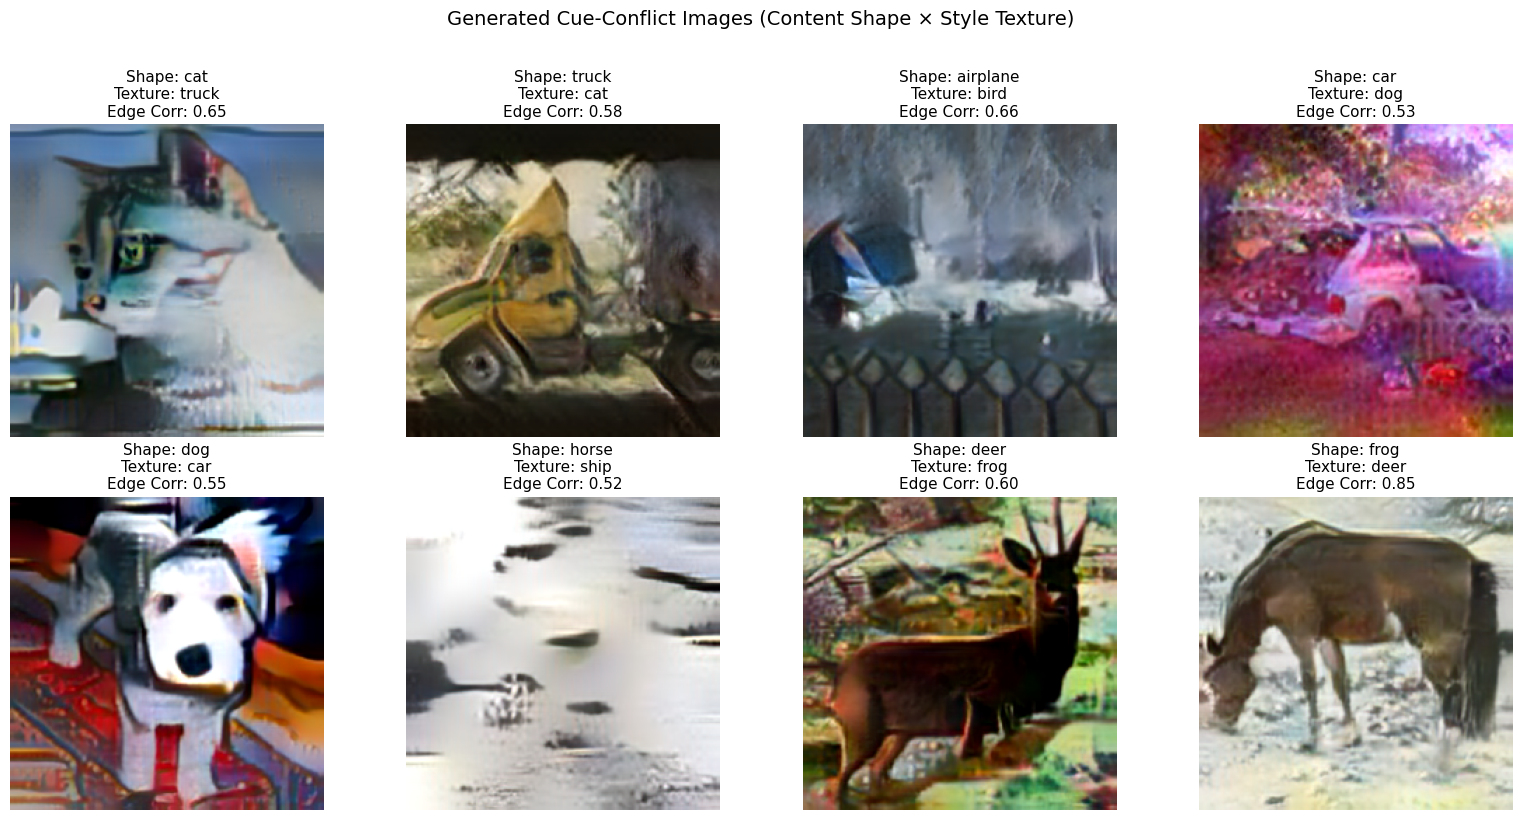

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
from task1.configs.config import RESULTS_DIR

# 1. Load the generated cue-conflict data
conflict_path = os.path.join(RESULTS_DIR, "cue_conflict_data.pt")
if not os.path.exists(conflict_path):
    raise FileNotFoundError(f"Could not find {conflict_path}. Please make sure Step 3 generation has run.")

data = torch.load(conflict_path, map_location="cpu")
images = data["images"]
metadata = data["metadata"]

print(f"Total available cue-conflict images: {len(images)}")

# 2. Display a sample grid of 8 cue-conflict images
num_samples = min(8, len(images))
# Sample evenly across the dataset to show different class pairs
indices = torch.linspace(0, len(images) - 1, steps=num_samples).long()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for plot_idx, img_idx in enumerate(indices):
    img = images[img_idx].permute(1, 2, 0).clamp(0.0, 1.0).numpy()
    meta = metadata[img_idx]

    shape_name = meta["shape_name"]
    texture_name = meta["texture_name"]
    edge_corr = meta.get("edge_corr", None)

    axes[plot_idx].imshow(img)
    title = f"Shape: {shape_name}\nTexture: {texture_name}"
    if edge_corr is not None:
        title += f"\nEdge Corr: {edge_corr:.2f}"
    axes[plot_idx].set_title(title, fontsize=11)
    axes[plot_idx].axis("off")

plt.suptitle("Generated Cue-Conflict Images (Content Shape × Style Texture)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "sample_cue_conflicts.png"), bbox_inches="tight")
plt.show()

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision.transforms import functional as TF
from sklearn.metrics import accuracy_score
import open_clip

from task1.configs.config import DEVICE, STL10_CLASSES, RESULTS_DIR
from task1.data.make_subset import get_datasets
from task1.models.backbones import load_backbones

# 1. Load data, backbones, and checkpoints
_, _, eval_subset = get_datasets()
backbones, norms = load_backbones(DEVICE)

CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "checkpoints")
probe_dims = {"resnet50": 2048, "vit_b16": 768, "clip": 512}
models_list = ["resnet50", "vit_b16", "clip"]
trained_heads = {}

for m in models_list:
    head = torch.nn.Linear(probe_dims[m], 10).to(DEVICE)
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"{m}_probe.pth")
    head.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    head.eval()
    trained_heads[m] = head

# Load Zero-Shot CLIP setup
tokenizer = open_clip.get_tokenizer("ViT-B-32")
prompts = [f"a photo of a {c}." for c in STL10_CLASSES]
text_tokens = tokenizer(prompts).to(DEVICE)
with torch.no_grad():
    text_features = backbones["clip"].encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
logit_scale = backbones["clip"].logit_scale.exp()

# Load saved clean metrics to retrieve clean baseline predictions y_hat(x_i)
clean_metrics_path = os.path.join(RESULTS_DIR, "clean_metrics.pt")
clean_data = torch.load(clean_metrics_path, map_location="cpu")

# Extract original clean images and ground truth labels
clean_imgs = torch.stack([eval_subset[i][0] for i in range(len(eval_subset))], dim=0)
eval_targets = torch.tensor([eval_subset[i][1] for i in range(len(eval_subset))])

# -------------------------------------------------------------------------
# Translation Transformation Engine (Reflection Padding + Shifted Crop)
# -------------------------------------------------------------------------
def translate_tensor(img_batch, shift_x, shift_y):
    """
    Translates a batch of images [B, C, H, W] using reflection padding.
    shift_x > 0: shift right | shift_x < 0: shift left
    shift_y > 0: shift down  | shift_y < 0: shift up
    """
    b, c, h, w = img_batch.shape
    pad = max(abs(shift_x), abs(shift_y))
    if pad == 0:
        return img_batch
    padded = TF.pad(img_batch, padding=pad, padding_mode="reflect")
    # top-left corner of the crop
    top = pad - shift_y
    left = pad - shift_x
    return TF.crop(padded, top=top, left=left, height=h, width=w)

# -------------------------------------------------------------------------
# Evaluation Across Displacements
# -------------------------------------------------------------------------
displacements = [0, 8, 16, 32]
all_model_names = [
    "RESNET50 Linear Probe",
    "VIT_B16 Linear Probe",
    "CLIP Linear Probe",
    "OpenCLIP ViT-B/32 Zero-Shot"
]

results_records = []

for delta in displacements:
    print(f"\nEvaluating displacement delta = {delta} px...")
    if delta == 0:
        directions = [(0, 0)]
    else:
        # Four cardinal directions: (dx, dy)
        directions = [(0, delta), (0, -delta), (-delta, 0), (delta, 0)]

    dir_accs = {m: [] for m in all_model_names}
    dir_cons = {m: [] for m in all_model_names}

    for shift_x, shift_y in directions:
        shifted_imgs = translate_tensor(clean_imgs, shift_x, shift_y)
        loader = torch.utils.data.DataLoader(shifted_imgs, batch_size=128, shuffle=False)

        feats = {"resnet50": [], "vit_b16": [], "clip": []}
        use_amp = torch.cuda.is_available()
        with torch.no_grad():
            for b_imgs in loader:
                b_imgs = b_imgs.to(DEVICE)
                with torch.amp.autocast("cuda", enabled=use_amp):
                    feats["resnet50"].append(backbones["resnet50"](norms["resnet50"](b_imgs)).cpu().float())
                    feats["vit_b16"].append(backbones["vit_b16"](norms["vit_b16"](b_imgs)).cpu().float())
                    fc = backbones["clip"].encode_image(norms["clip"](b_imgs))
                    feats["clip"].append((fc / fc.norm(dim=-1, keepdim=True)).cpu().float())

        feats = {k: torch.cat(v, dim=0) for k, v in feats.items()}

        # 1. Probes
        for m in models_list:
            key = f"{m.upper()} Linear Probe"
            with torch.no_grad():
                logits = trained_heads[m](feats[m].to(DEVICE))
                preds = logits.argmax(dim=-1).cpu()

            acc = accuracy_score(eval_targets, preds) * 100.0
            clean_preds = clean_data[key]["preds"]
            consistency = (preds == clean_preds).float().mean().item() * 100.0

            dir_accs[key].append(acc)
            dir_cons[key].append(consistency)

        # 2. Zero-Shot CLIP
        zs_key = "OpenCLIP ViT-B/32 Zero-Shot"
        with torch.no_grad():
            sims = (feats["clip"].to(DEVICE) @ text_features.T) * logit_scale
            zs_preds = sims.argmax(dim=-1).cpu()

        acc_zs = accuracy_score(eval_targets, zs_preds) * 100.0
        clean_zs_preds = clean_data[zs_key]["preds"]
        cons_zs = (zs_preds == clean_zs_preds).float().mean().item() * 100.0

        dir_accs[zs_key].append(acc_zs)
        dir_cons[zs_key].append(cons_zs)

    # Average across the four directions
    for model_name in all_model_names:
        mean_acc = float(np.mean(dir_accs[model_name]))
        mean_cons = float(np.mean(dir_cons[model_name]))
        results_records.append({
            "Model": model_name,
            "Displacement (delta)": delta,
            "Mean Accuracy (%)": round(mean_acc, 2),
            "Mean Consistency (%)": round(mean_cons, 2)
        })

df_translation = pd.DataFrame(results_records)
df_translation.to_csv(os.path.join(RESULTS_DIR, "step4_translation.csv"), index=False)
display(df_translation)

/usr/local/lib/python3.13/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(



Evaluating displacement delta = 0 px...

Evaluating displacement delta = 8 px...

Evaluating displacement delta = 16 px...

Evaluating displacement delta = 32 px...


,Model,Displacement (delta),Mean Accuracy (%),Mean Consistency (%)
0,RESNET50 Linear Probe,0,97.60,100.00
1,VIT_B16 Linear Probe,0,97.00,100.00
2,CLIP Linear Probe,0,97.20,100.00
3,OpenCLIP ViT-B/32 Zero-Shot,0,75.80,100.00
4,RESNET50 Linear Probe,8,96.95,98.60
5,VIT_B16 Linear Probe,8,96.40,98.30
6,CLIP Linear Probe,8,97.10,97.30
7,OpenCLIP ViT-B/32 Zero-Shot,8,76.75,95.50
8,RESNET50 Linear Probe,16,96.65,98.55
9,VIT_B16 Linear Probe,16,96.40,98.55


<>:32: SyntaxWarning: invalid escape sequence '\d'
<>:40: SyntaxWarning: invalid escape sequence '\d'
<>:41: SyntaxWarning: invalid escape sequence '\d'
<>:32: SyntaxWarning: invalid escape sequence '\d'
<>:40: SyntaxWarning: invalid escape sequence '\d'
<>:41: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_855/3222178909.py:32: SyntaxWarning: invalid escape sequence '\d'
  ax1.set_xlabel("Displacement $\delta$ (pixels)", fontsize=11)
/tmp/ipykernel_855/3222178909.py:40: SyntaxWarning: invalid escape sequence '\d'
  ax2.set_xlabel("Displacement $\delta$ (pixels)", fontsize=11)
/tmp/ipykernel_855/3222178909.py:41: SyntaxWarning: invalid escape sequence '\d'
  ax2.set_ylabel("Consistency( $\delta$ ) (%)", fontsize=11)


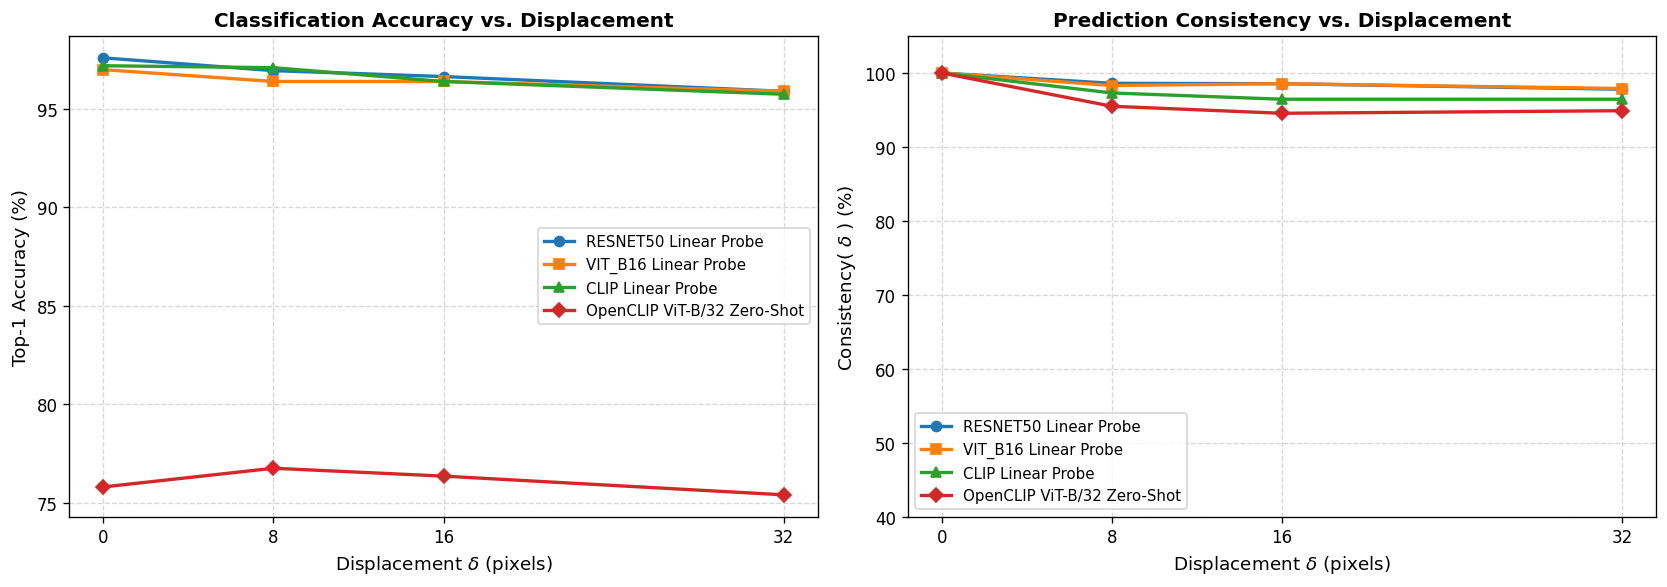

Translation curve plot saved to task1/results/translation_curves.png


In [ ]:
# -------------------------------------------------------------------------
# Plotting Accuracy and Consistency Curves
# -------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

colors = {
    "RESNET50 Linear Probe": "#1f77b4",
    "VIT_B16 Linear Probe": "#ff7f0e",
    "CLIP Linear Probe": "#2ca02c",
    "OpenCLIP ViT-B/32 Zero-Shot": "#d62728"
}
markers = {
    "RESNET50 Linear Probe": "o",
    "VIT_B16 Linear Probe": "s",
    "CLIP Linear Probe": "^",
    "OpenCLIP ViT-B/32 Zero-Shot": "D"
}

for model_name in all_model_names:
    sub_df = df_translation[df_translation["Model"] == model_name]
    deltas = sub_df["Displacement (delta)"]
    accs = sub_df["Mean Accuracy (%)"]
    cons = sub_df["Mean Consistency (%)"]

    ax1.plot(deltas, accs, label=model_name, color=colors[model_name],
             marker=markers[model_name], linewidth=2, markersize=6)
    ax2.plot(deltas, cons, label=model_name, color=colors[model_name],
             marker=markers[model_name], linewidth=2, markersize=6)

# Accuracy Subplot Formatting
ax1.set_title("Classification Accuracy vs. Displacement", fontsize=12, fontweight="bold")
ax1.set_xlabel("Displacement $\delta$ (pixels)", fontsize=11)
ax1.set_ylabel("Top-1 Accuracy (%)", fontsize=11)
ax1.set_xticks(displacements)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(fontsize=9)

# Consistency Subplot Formatting
ax2.set_title("Prediction Consistency vs. Displacement", fontsize=12, fontweight="bold")
ax2.set_xlabel("Displacement $\delta$ (pixels)", fontsize=11)
ax2.set_ylabel("Consistency( $\delta$ ) (%)", fontsize=11)
ax2.set_xticks(displacements)
ax2.set_ylim(40, 105)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(fontsize=9)

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, "translation_curves.png")
plt.savefig(plot_path, bbox_inches="tight")
plt.show()
print(f"Translation curve plot saved to {plot_path}")

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
import open_clip

from task1.configs.config import SEED, DEVICE, STL10_CLASSES, RESULTS_DIR
from task1.data.make_subset import get_datasets
from task1.models.backbones import load_backbones
from task1.data.transforms import apply_patch_shuffle_4x4

# -------------------------------------------------------------------------
# 1. Load Data, Models, and Saved Checkpoints
# -------------------------------------------------------------------------
_, _, eval_subset = get_datasets()
backbones, norms = load_backbones(DEVICE)

CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "checkpoints")
probe_dims = {"resnet50": 2048, "vit_b16": 768, "clip": 512}
models_list = ["resnet50", "vit_b16", "clip"]
trained_heads = {}

for m in models_list:
    head = torch.nn.Linear(probe_dims[m], 10).to(DEVICE)
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"{m}_probe.pth")
    head.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    head.eval()
    trained_heads[m] = head

# Load Zero-Shot CLIP setup
tokenizer = open_clip.get_tokenizer("ViT-B-32")
prompts = [f"a photo of a {c}." for c in STL10_CLASSES]
text_tokens = tokenizer(prompts).to(DEVICE)
with torch.no_grad():
    text_features = backbones["clip"].encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
logit_scale = backbones["clip"].logit_scale.exp()

# Load clean baseline metrics for consistency calculation
clean_metrics_path = os.path.join(RESULTS_DIR, "clean_metrics.pt")
clean_data = torch.load(clean_metrics_path, map_location="cpu")
eval_targets = torch.tensor([eval_subset[i][1] for i in range(len(eval_subset))])

# -------------------------------------------------------------------------
# 2. Generate and Cache 4x4 Shuffled Images (Seed 6304)
# -------------------------------------------------------------------------
print("Generating 4x4 non-identity patch permutations for all 500 eval images...")
shuffled_imgs = []

for i in range(len(eval_subset)):
    img_tensor = eval_subset[i][0]
    # Deterministic non-identity generator seeded with base seed 6304
    gen = torch.Generator().manual_seed(SEED + i)
    shuffled_img = apply_patch_shuffle_4x4(img_tensor, gen)
    shuffled_imgs.append(shuffled_img)

shuffled_imgs = torch.stack(shuffled_imgs, dim=0)

# Save images for Step 6 representation analysis (t-SNE/UMAP)
torch.save(shuffled_imgs, os.path.join(RESULTS_DIR, "patch_shuffled_images.pt"))

# -------------------------------------------------------------------------
# 3. Extract Representations Across All Backbones
# -------------------------------------------------------------------------
loader = torch.utils.data.DataLoader(shuffled_imgs, batch_size=128, shuffle=False)
feats = {"resnet50": [], "vit_b16": [], "clip": []}
use_amp = torch.cuda.is_available()

with torch.no_grad():
    for b_imgs in loader:
        b_imgs = b_imgs.to(DEVICE)
        with torch.amp.autocast("cuda", enabled=use_amp):
            feats["resnet50"].append(backbones["resnet50"](norms["resnet50"](b_imgs)).cpu().float())
            feats["vit_b16"].append(backbones["vit_b16"](norms["vit_b16"](b_imgs)).cpu().float())
            fc = backbones["clip"].encode_image(norms["clip"](b_imgs))
            feats["clip"].append((fc / fc.norm(dim=-1, keepdim=True)).cpu().float())

feats = {k: torch.cat(v, dim=0) for k, v in feats.items()}

# Cache shuffled features for Step 6 representation similarity (I_T)
torch.save(feats, os.path.join(RESULTS_DIR, "patch_shuffled_features.pt"))

# -------------------------------------------------------------------------
# 4. Evaluate Accuracy Drop and Consistency
# -------------------------------------------------------------------------
records = []

# Evaluate the 3 Probes
for m in models_list:
    key = f"{m.upper()} Linear Probe"
    with torch.no_grad():
        logits = trained_heads[m](feats[m].to(DEVICE))
        preds = logits.argmax(dim=-1).cpu()

    acc = accuracy_score(eval_targets, preds) * 100.0
    clean_preds = clean_data[key]["preds"]
    consistency = (preds == clean_preds).float().mean().item() * 100.0

    clean_acc = clean_data[key]["acc"]
    delta_abs = acc - clean_acc
    delta_rel = (delta_abs / clean_acc) * 100.0

    records.append({
        "Model": key,
        "Clean Acc (%)": clean_acc,
        "Shuffled Acc (%)": round(acc, 2),
        "Δ Acc Abs (%)": round(delta_abs, 2),
        "Δ Acc Rel (%)": round(delta_rel, 2),
        "Consistency (%)": round(consistency, 2)
    })

# Evaluate Zero-Shot CLIP
zs_key = "OpenCLIP ViT-B/32 Zero-Shot"
with torch.no_grad():
    sims = (feats["clip"].to(DEVICE) @ text_features.T) * logit_scale
    zs_preds = sims.argmax(dim=-1).cpu()

acc_zs = accuracy_score(eval_targets, zs_preds) * 100.0
clean_zs_preds = clean_data[zs_key]["preds"]
cons_zs = (zs_preds == clean_zs_preds).float().mean().item() * 100.0

clean_acc_zs = clean_data[zs_key]["acc"]
delta_abs_zs = acc_zs - clean_acc_zs
delta_rel_zs = (delta_abs_zs / clean_acc_zs) * 100.0

records.append({
    "Model": zs_key,
    "Clean Acc (%)": clean_acc_zs,
    "Shuffled Acc (%)": round(acc_zs, 2),
    "Δ Acc Abs (%)": round(delta_abs_zs, 2),
    "Δ Acc Rel (%)": round(delta_rel_zs, 2),
    "Consistency (%)": round(cons_zs, 2)
})

# Display and export
df_shuffled = pd.DataFrame(records)
display(df_shuffled)
df_shuffled.to_csv(os.path.join(RESULTS_DIR, "step5_patch_shuffle.csv"), index=False)
print("Step 5 Patch Shuffle evaluation complete. Results saved to task1/results/step5_patch_shuffle.csv")

/usr/local/lib/python3.13/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Generating 4x4 non-identity patch permutations for all 500 eval images...


,Model,Clean Acc (%),Shuffled Acc (%),Δ Acc Abs (%),Δ Acc Rel (%),Consistency (%)
0,RESNET50 Linear Probe,97.6,88.6,-9.0,-9.22,88.8
1,VIT_B16 Linear Probe,97.0,89.2,-7.8,-8.04,90.8
2,CLIP Linear Probe,97.2,82.8,-14.4,-14.81,82.8
3,OpenCLIP ViT-B/32 Zero-Shot,75.8,65.6,-10.2,-13.46,77.4


Step 5 Patch Shuffle evaluation complete. Results saved to task1/results/step5_patch_shuffle.csv


/usr/local/lib/python3.13/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Extracting features for Step 6 interventions...


,Intervention,Backbone,Cosine Stability (I_T)
0,Grayscale,RESNET50,0.7885
1,Grayscale,VIT_B16,0.7369
2,Grayscale,CLIP,0.8962
3,Translation (32px),RESNET50,0.9755
4,Translation (32px),VIT_B16,0.9793
5,Translation (32px),CLIP,0.9858
6,Patch Shuffle (4x4),RESNET50,0.7193
7,Patch Shuffle (4x4),VIT_B16,0.6539
8,Patch Shuffle (4x4),CLIP,0.7332
9,Cue Conflict,RESNET50,0.2114



Generating joint t-SNE projections...


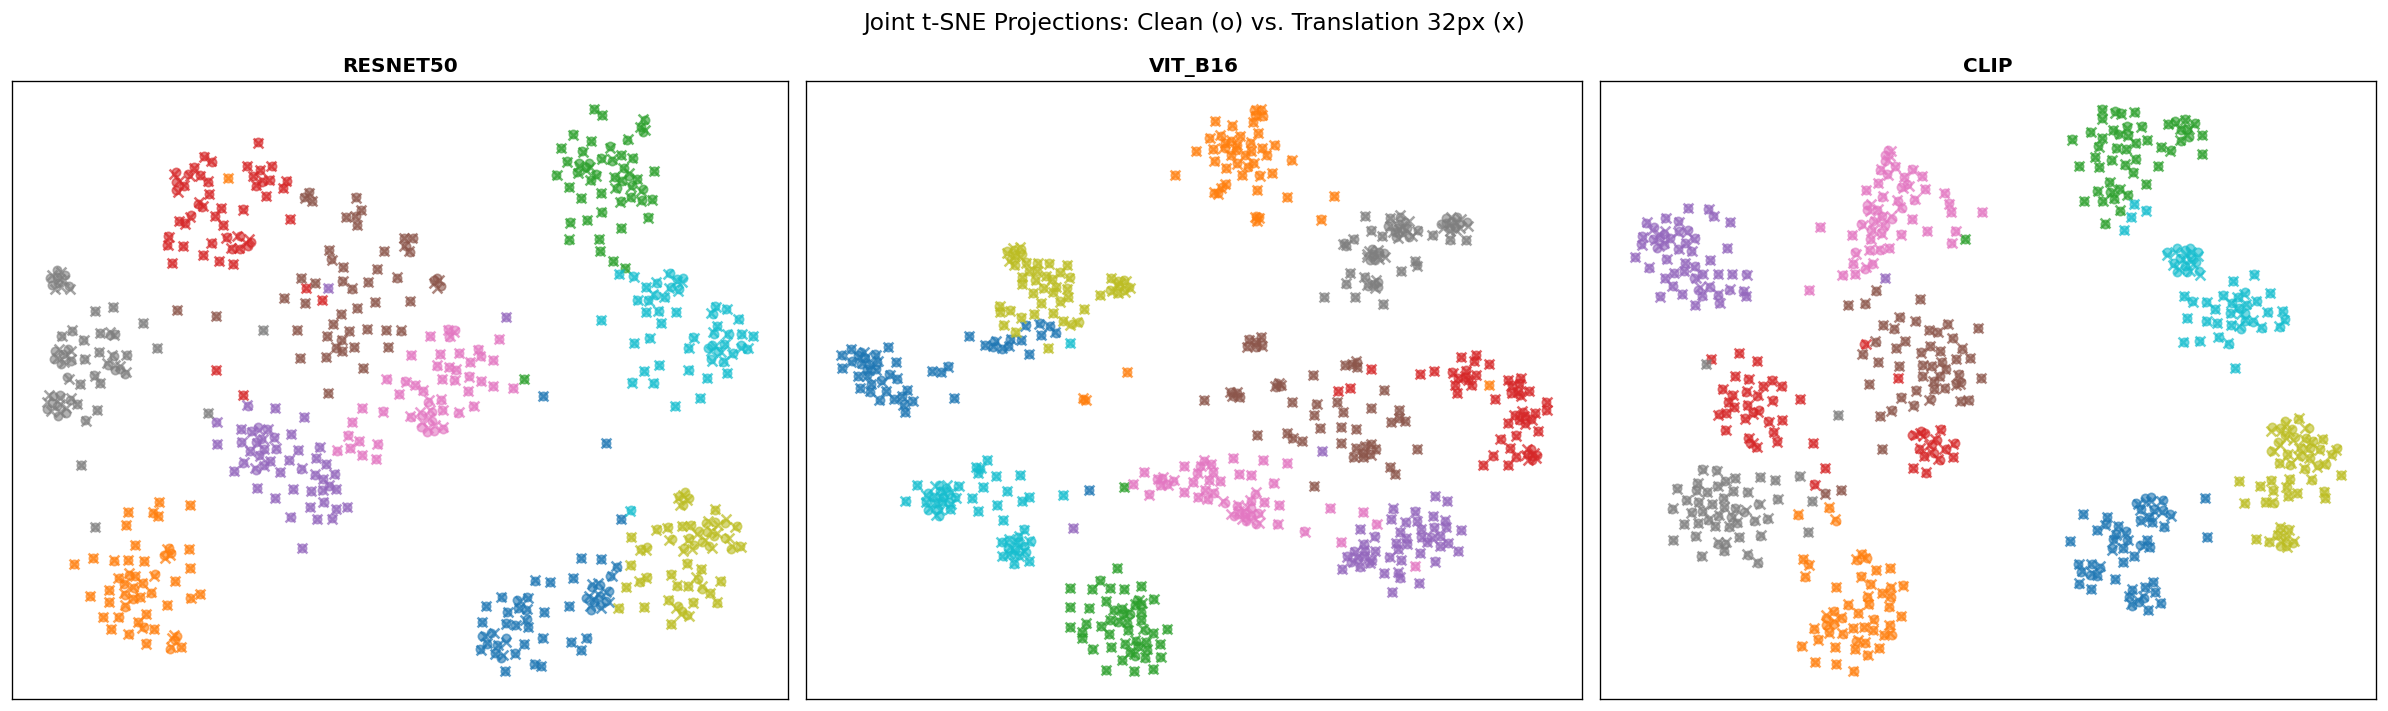

Saved t-SNE figure to task1/results/tsne_plots/tsne_Translation_32px.png


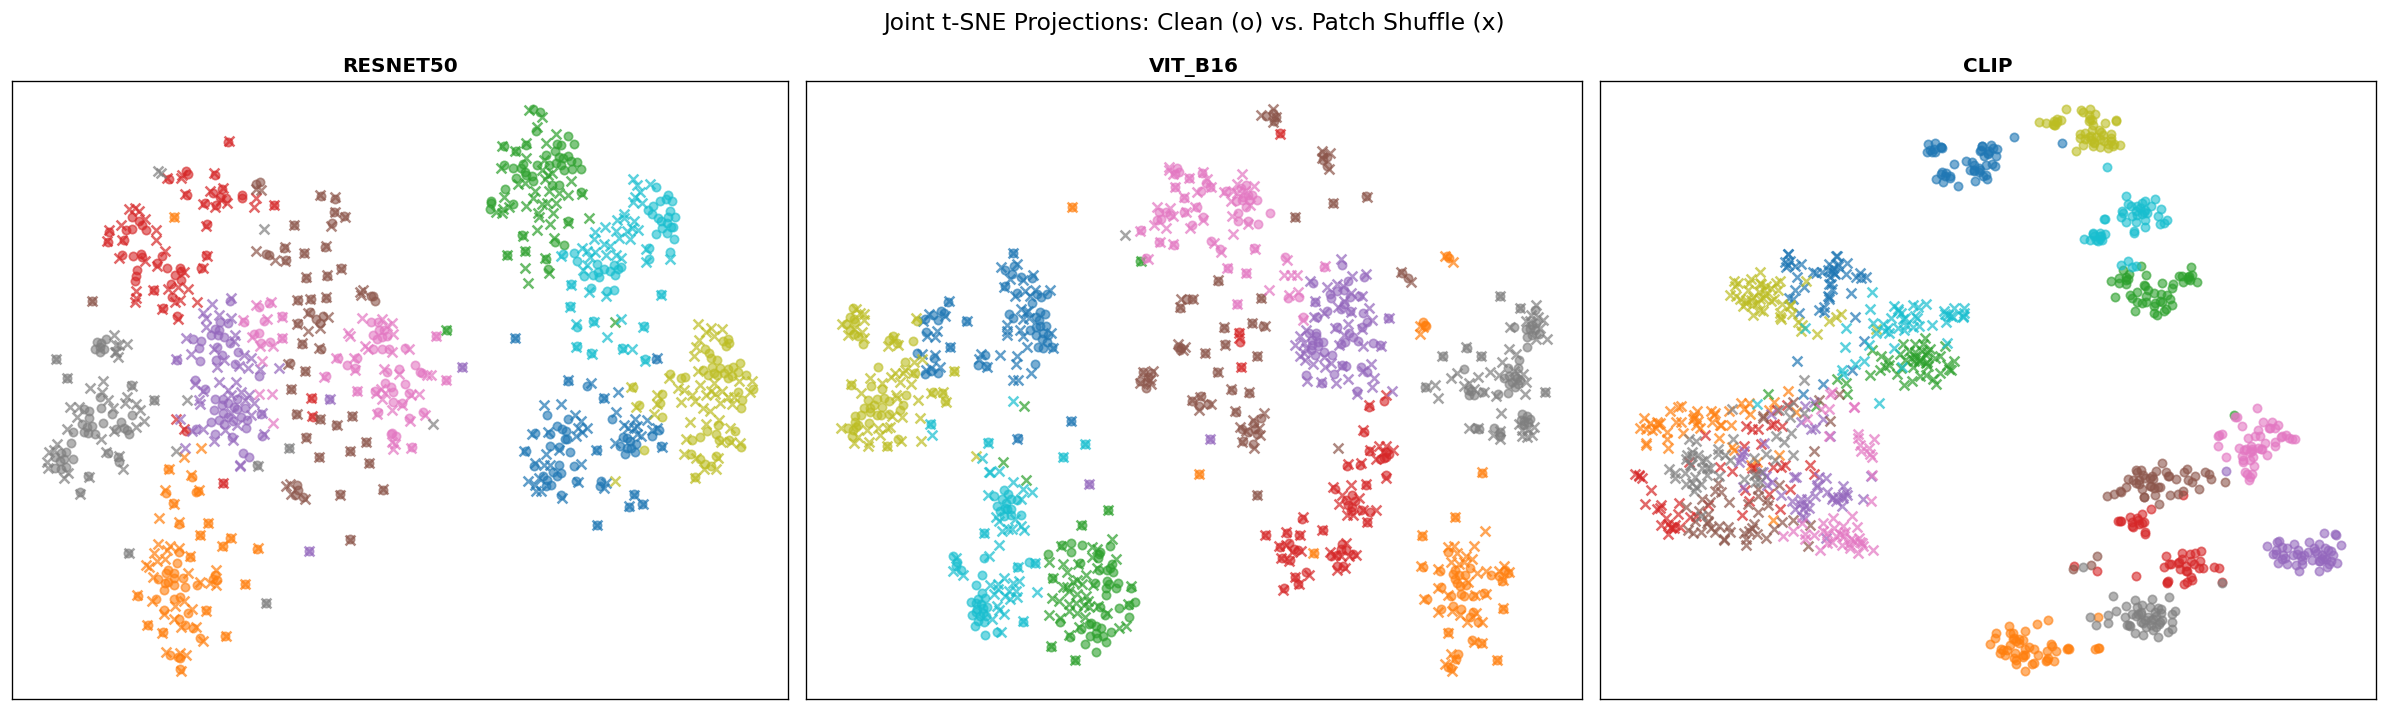

Saved t-SNE figure to task1/results/tsne_plots/tsne_Patch_Shuffle.png


In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch.nn.functional as F

from task1.configs.config import SEED, DEVICE, STL10_CLASSES, RESULTS_DIR
from task1.data.make_subset import get_datasets
from task1.models.backbones import load_backbones
from task1.data.transforms import apply_grayscale, apply_patch_shuffle_4x4, apply_translation

# -------------------------------------------------------------------------
# 1. Load Data, Models, and Clean Evaluation Features
# -------------------------------------------------------------------------
_, _, eval_subset = get_datasets()
backbones, norms = load_backbones(DEVICE)

models_list = ["resnet50", "vit_b16", "clip"]

# Extract original clean images and ground truth labels
clean_imgs = torch.stack([eval_subset[i][0] for i in range(len(eval_subset))], dim=0)
eval_targets = torch.tensor([eval_subset[i][1] for i in range(len(eval_subset))])

# Extract/load clean representations
clean_feats_path = os.path.join(RESULTS_DIR, "clean_eval_features.pt")
if os.path.exists(clean_feats_path):
    clean_feats_raw = torch.load(clean_feats_path, map_location="cpu")
    feats_clean = {m: clean_feats_raw[m][0] for m in models_list}
else:
    loader = torch.utils.data.DataLoader(clean_imgs, batch_size=128, shuffle=False)
    feats_clean = {"resnet50": [], "vit_b16": [], "clip": []}
    use_amp = torch.cuda.is_available()
    with torch.no_grad():
        for b in loader:
            b = b.to(DEVICE)
            with torch.amp.autocast("cuda", enabled=use_amp):
                feats_clean["resnet50"].append(backbones["resnet50"](norms["resnet50"](b)).cpu().float())
                feats_clean["vit_b16"].append(backbones["vit_b16"](norms["vit_b16"](b)).cpu().float())
                fc = backbones["clip"].encode_image(norms["clip"](b))
                feats_clean["clip"].append((fc / fc.norm(dim=-1, keepdim=True)).cpu().float())
    feats_clean = {k: torch.cat(v, dim=0) for k, v in feats_clean.items()}

# -------------------------------------------------------------------------
# 2. Extract Features for Grayscale, Translation (32px), and Patch Shuffling
# -------------------------------------------------------------------------
@torch.no_grad()
def extract_batch_features(img_tensors):
    loader = torch.utils.data.DataLoader(img_tensors, batch_size=128, shuffle=False)
    feats = {"resnet50": [], "vit_b16": [], "clip": []}
    use_amp = torch.cuda.is_available()
    for b in loader:
        b = b.to(DEVICE)
        with torch.amp.autocast("cuda", enabled=use_amp):
            feats["resnet50"].append(backbones["resnet50"](norms["resnet50"](b)).cpu().float())
            feats["vit_b16"].append(backbones["vit_b16"](norms["vit_b16"](b)).cpu().float())
            fc = backbones["clip"].encode_image(norms["clip"](b))
            feats["clip"].append((fc / fc.norm(dim=-1, keepdim=True)).cpu().float())
    return {k: torch.cat(v, dim=0) for k, v in feats.items()}

print("Extracting features for Step 6 interventions...")

# A. Grayscale
gray_imgs = torch.stack([apply_grayscale(clean_imgs[i]) for i in range(len(clean_imgs))], dim=0)
feats_gray = extract_batch_features(gray_imgs)

# B. Translation (Delta = 32px, averaged across 4 directions)
feats_trans_dirs = {m: [] for m in models_list}
for dx, dy in [(0, 32), (0, -32), (-32, 0), (32, 0)]:
    # Apply translation to each image individually and stack them
    shifted_imgs_batch = torch.stack([apply_translation(img, dx, dy) for img in clean_imgs], dim=0)
    f_shifted = extract_batch_features(shifted_imgs_batch)
    for m in models_list:
        feats_trans_dirs[m].append(f_shifted[m])
feats_trans = {m: torch.stack(feats_trans_dirs[m], dim=0).mean(dim=0) for m in models_list}

# C. Patch Shuffle
shuffled_path = os.path.join(RESULTS_DIR, "patch_shuffled_features.pt")
if os.path.exists(shuffled_path):
    feats_shuff = torch.load(shuffled_path, map_location="cpu")
else:
    shuff_imgs = []
    for i in range(len(clean_imgs)):
        gen = torch.Generator().manual_seed(SEED + i)
        shuff_imgs.append(apply_patch_shuffle_4x4(clean_imgs[i], gen))
    feats_shuff = extract_batch_features(torch.stack(shuff_imgs, dim=0))

# D. Cue Conflict (Paired against un-stylized content source images)
conflict_path = os.path.join(RESULTS_DIR, "cue_conflict_data.pt")
conflict_data = torch.load(conflict_path, map_location="cpu")
conflict_imgs = conflict_data["images"]
conflict_meta = conflict_data["metadata"]

# Extract clean source images corresponding to content shapes
class_buckets = {c: [] for c in STL10_CLASSES}
for i in range(len(eval_subset)):
    img, label = eval_subset[i]
    class_buckets[STL10_CLASSES[label]].append(img)

clean_cue_sources = []
for meta in conflict_meta:
    # Retrieve the corresponding content exemplar
    clean_cue_sources.append(class_buckets[meta["shape_name"]][0])
clean_cue_sources = torch.stack(clean_cue_sources, dim=0)

feats_cue_trans = extract_batch_features(conflict_imgs)
feats_cue_clean = extract_batch_features(clean_cue_sources)
cue_targets = torch.tensor([m["shape_label"] for m in conflict_meta])

# -------------------------------------------------------------------------
# 3. Compute Cosine Stability (I_T) Table
# -------------------------------------------------------------------------
def compute_it(clean_f, trans_f):
    c_norm = clean_f / clean_f.norm(dim=-1, keepdim=True)
    t_norm = trans_f / trans_f.norm(dim=-1, keepdim=True)
    sims = (c_norm * t_norm).sum(dim=-1)
    return float(sims.mean().item())

interventions = [
    ("Grayscale", feats_clean, feats_gray),
    ("Translation (32px)", feats_clean, feats_trans),
    ("Patch Shuffle (4x4)", feats_clean, feats_shuff),
    ("Cue Conflict", feats_cue_clean, feats_cue_trans)
]

it_records = []
for int_name, c_dict, t_dict in interventions:
    for m in models_list:
        val = compute_it(c_dict[m], t_dict[m])
        it_records.append({
            "Intervention": int_name,
            "Backbone": m.upper(),
            "Cosine Stability (I_T)": round(val, 4)
        })

df_it = pd.DataFrame(it_records)
display(df_it)
df_it.to_csv(os.path.join(RESULTS_DIR, "step6_representation_stability.csv"), index=False)

# -------------------------------------------------------------------------
# 4. Joint t-SNE Manifold Visualizations
# -------------------------------------------------------------------------
print("\nGenerating joint t-SNE projections...")
os.makedirs(os.path.join(RESULTS_DIR, "tsne_plots"), exist_ok=True)

# Select 2 representative interventions for comparative plotting: Translation vs. Patch Shuffle
plot_interventions = [
    ("Translation_32px", feats_clean, feats_trans, eval_targets),
    ("Patch_Shuffle", feats_clean, feats_shuff, eval_targets)
]

cmap = plt.get_cmap("tab10")

for int_label, c_dict, t_dict, targets in plot_interventions:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=120)
    n = len(targets)

    for ax_idx, m in enumerate(models_list):
        f_c = c_dict[m].numpy()
        f_t = t_dict[m].numpy()

        # Combine clean and transformed instances to fit in one unified projection
        combined = np.concatenate([f_c, f_t], axis=0)

        tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, metric="cosine")
        emb = tsne.fit_transform(combined)

        emb_clean = emb[:n]
        emb_trans = emb[n:]

        for c in range(10):
            mask = (targets.numpy() == c)
            axes[ax_idx].scatter(
                emb_clean[mask, 0], emb_clean[mask, 1],
                color=cmap(c), marker="o", alpha=0.6, s=25,
                label=STL10_CLASSES[c] if (ax_idx == 0 and c < 10) else ""
            )
            axes[ax_idx].scatter(
                emb_trans[mask, 0], emb_trans[mask, 1],
                color=cmap(c), marker="x", alpha=0.7, s=35
            )

        axes[ax_idx].set_title(f"{m.upper()}", fontsize=12, fontweight="bold")
        axes[ax_idx].set_xticks([])
        axes[ax_idx].set_yticks([])

    fig.suptitle(f"Joint t-SNE Projections: Clean (o) vs. {int_label.replace('_', ' ')} (x)", fontsize=14, y=0.98)
    if ax_idx == 0:
        axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    plt.tight_layout()
    save_path = os.path.join(RESULTS_DIR, "tsne_plots", f"tsne_{int_label}.png")
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    print(f"Saved t-SNE figure to {save_path}")

/usr/local/lib/python3.13/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


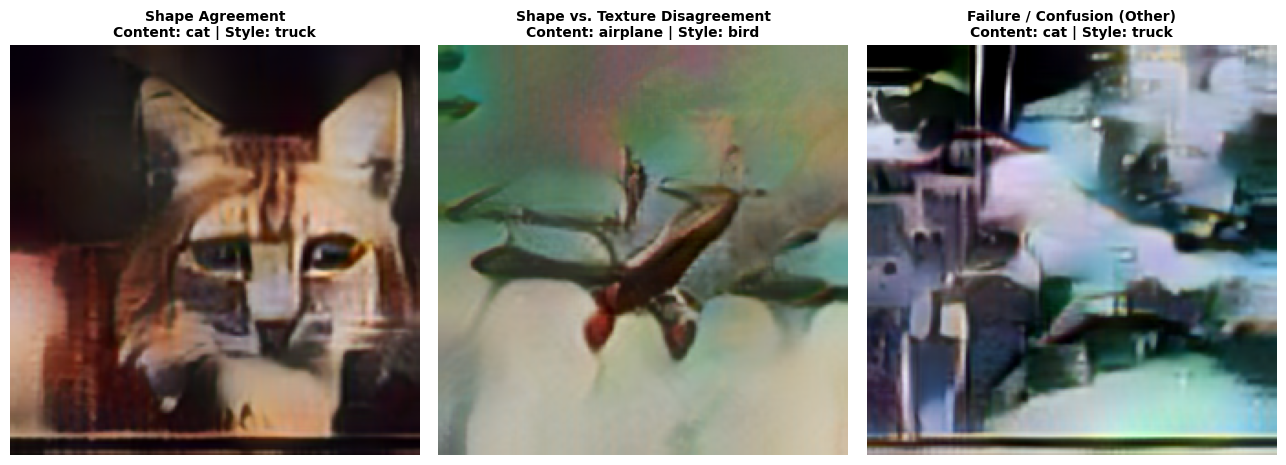

,Case Type,Shape (Content),Texture (Style),ResNet-50 Pred,ViT-B/16 Pred,CLIP Probe Pred,Zero-Shot CLIP Pred
0,Shape Agreement,cat,truck,cat,cat,cat,cat
1,Shape vs. Texture Disagreement,airplane,bird,bird,airplane,airplane,airplane
2,Failure / Confusion (Other),cat,truck,ship,ship,truck,bird


In [ ]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
from task1.configs.config import DEVICE, STL10_CLASSES, RESULTS_DIR
from task1.models.backbones import load_backbones
import open_clip

# 1. Load data, models, and checkpoints
data = torch.load(os.path.join(RESULTS_DIR, "cue_conflict_data.pt"), map_location="cpu")
images = data["images"]
metadata = data["metadata"]

backbones, norms = load_backbones(DEVICE)
CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "checkpoints")
probe_dims = {"resnet50": 2048, "vit_b16": 768, "clip": 512}
trained_heads = {}
for m in ["resnet50", "vit_b16", "clip"]:
    head = torch.nn.Linear(probe_dims[m], 10).to(DEVICE)
    head.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, f"{m}_probe.pth"), map_location=DEVICE))
    head.eval()
    trained_heads[m] = head

tokenizer = open_clip.get_tokenizer("ViT-B-32")
prompts = [f"a photo of a {c}." for c in STL10_CLASSES]
text_tokens = tokenizer(prompts).to(DEVICE)
with torch.no_grad():
    text_features = backbones["clip"].encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
logit_scale = backbones["clip"].logit_scale.exp()

# 2. Collect predictions per image
cases = []
loader = torch.utils.data.DataLoader(images, batch_size=64, shuffle=False)
feats = {"resnet50": [], "vit_b16": [], "clip": []}
use_amp = torch.cuda.is_available()

with torch.no_grad():
    for b in loader:
        b = b.to(DEVICE)
        with torch.amp.autocast("cuda", enabled=use_amp):
            feats["resnet50"].append(backbones["resnet50"](norms["resnet50"](b)).cpu().float())
            feats["vit_b16"].append(backbones["vit_b16"](norms["vit_b16"](b)).cpu().float())
            fc = backbones["clip"].encode_image(norms["clip"](b))
            feats["clip"].append((fc / fc.norm(dim=-1, keepdim=True)).cpu().float())

feats = {k: torch.cat(v, dim=0) for k, v in feats.items()}

preds_r50 = trained_heads["resnet50"](feats["resnet50"].to(DEVICE)).argmax(dim=-1).cpu()
preds_vit = trained_heads["vit_b16"](feats["vit_b16"].to(DEVICE)).argmax(dim=-1).cpu()
preds_clip = trained_heads["clip"](feats["clip"].to(DEVICE)).argmax(dim=-1).cpu()
sims_zs = (feats["clip"].to(DEVICE) @ text_features.T) * logit_scale
preds_zs = sims_zs.argmax(dim=-1).cpu()

# 3. Find key examples: Agreement, Shape/Texture Disagreement, and Failure (Other)
found_agreement = None
found_disagreement = None
found_failure = None

for i in range(len(images)):
    ys = metadata[i]["shape_label"]
    yt = metadata[i]["texture_label"]
    p_r = preds_r50[i].item()
    p_v = preds_vit[i].item()
    p_c = preds_clip[i].item()
    p_z = preds_zs[i].item()

    # Case A: Shape Agreement (all models choose shape)
    if found_agreement is None and (p_r == ys and p_v == ys and p_c == ys and p_z == ys):
        found_agreement = (i, "Shape Agreement")
    # Case B: Disagreement (ResNet picks texture, ViT/CLIP pick shape)
    if found_disagreement is None and (p_r == yt and p_v == ys and p_c == ys):
        found_disagreement = (i, "Shape vs. Texture Disagreement")
    # Case C: Failure (models pick an unrelated 'other' class)
    if found_failure is None and (p_r not in [ys, yt] and p_v not in [ys, yt]):
        found_failure = (i, "Failure / Confusion (Other)")

selected_cases = [found_agreement, found_disagreement, found_failure]
table_rows = []

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for idx, item in enumerate(selected_cases):
    if item is None: continue
    i, case_type = item
    img = images[i].permute(1, 2, 0).clamp(0, 1).numpy()
    meta = metadata[i]

    axes[idx].imshow(img)
    title = f"{case_type}\nContent: {meta['shape_name']} | Style: {meta['texture_name']}"
    axes[idx].set_title(title, fontsize=10, fontweight="bold")
    axes[idx].axis("off")

    table_rows.append({
        "Case Type": case_type,
        "Shape (Content)": meta["shape_name"],
        "Texture (Style)": meta["texture_name"],
        "ResNet-50 Pred": STL10_CLASSES[preds_r50[i]],
        "ViT-B/16 Pred": STL10_CLASSES[preds_vit[i]],
        "CLIP Probe Pred": STL10_CLASSES[preds_clip[i]],
        "Zero-Shot CLIP Pred": STL10_CLASSES[preds_zs[i]]
    })

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "cue_conflict_cases.png"), bbox_inches="tight")
plt.show()

df_cases = pd.DataFrame(table_rows)
display(df_cases)
df_cases.to_csv(os.path.join(RESULTS_DIR, "cue_conflict_informative_cases.csv"), index=False)

In [ ]:
# Cell 14: Persist Entire Task 1 Directory Structure and Checkpoints to Google Drive
import os
import shutil
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Set source and target paths
source_root = "task1"
target_drive_dir = "/content/drive/MyDrive/ATML_PA1/Task1"

# 3. Create target directory tree on Drive
os.makedirs(target_drive_dir, exist_ok=True)

# 4. Recursively mirror the entire directory structure into Drive
# (copies configs, data, models, analysis, scripts, results, checkpoints, .pt, and .pth files)
shutil.copytree(source_root, target_drive_dir, dirs_exist_ok=True)
print(f"Direct folder sync complete: '{source_root}' -> '{target_drive_dir}'")

# 5. Create an all-inclusive zip archive in the same Drive folder
zip_archive_path = os.path.join(target_drive_dir, "task1_complete_backup")
shutil.make_archive(zip_archive_path, "zip", root_dir=".", base_dir="task1")
print(f"Archive generated at: {zip_archive_path}.zip")

# 6. Verify contents transferred to Drive
print("\nContents saved to Drive:")
for root, dirs, files in os.walk(target_drive_dir):
    level = root.replace(target_drive_dir, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    sub_indent = " " * 4 * (level + 1)
    for f in files:
        print(f"{sub_indent}{f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Direct folder sync complete: 'task1' -> '/content/drive/MyDrive/ATML_PA1/Task1'
Archive generated at: /content/drive/MyDrive/ATML_PA1/Task1/task1_complete_backup.zip

Contents saved to Drive:
Task1/
    README.md
    __init__.py
    task1_complete_backup.zip
    configs/
        config.py
        __init__.py
        __pycache__/
            __init__.cpython-313.pyc
            config.cpython-313.pyc
    data/
        make_cue_conflicts.py
        transforms.py
        make_subset.py
        __init__.py
        __pycache__/
            make_subset.cpython-313.pyc
            __init__.cpython-313.pyc
            transforms.cpython-313.pyc
    models/
        backbones.py
        __init__.py
        __pycache__/
            __init__.cpython-313.pyc
            backbones.cpython-313.pyc
    results/
        step5_patch_shuffle.csv
        cue_conflict_informative